In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Yashvin\.cache\kagglehub\datasets\lakshmi25npathi\imdb-dataset-of-50k-movie-reviews\versions\1


In [2]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')  
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
!pip install nltk scikit-learn pandas numpy seaborn matplotlib

import pandas as pd
import numpy as np
import re
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Yashvin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
import os
file_path = os.path.join(path, "IMDB Dataset.csv")

df = pd.read_csv(file_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nClass Distribution:\n", df['sentiment'].value_counts())

print("\nSample Review:\n", df['review'][0])

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Chris

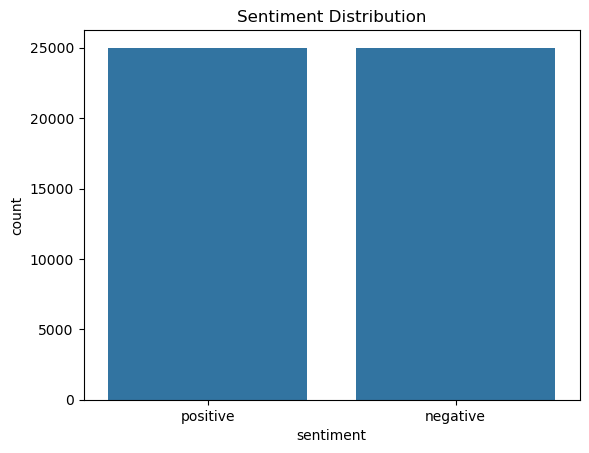

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [16]:
df = df.rename(columns={
    "review": "text",
    "sentiment": "label"
})

In [18]:
df['label'] = df['label'].map({
    'positive': 1,
    'negative': 0
})

In [20]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords + Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [29]:
df = df.sample(10000, random_state=42) 
df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
33553,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...
9427,Not many television shows appeal to quite as m...,many television show appeal quite many differe...
199,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...
12447,Jane Austen would definitely approve of this o...,jane austen would definitely approve onegwynet...
39489,Expectations were somewhat high for me when I ...,expectation somewhat high went see movie thoug...


In [31]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [37]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [39]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [43]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [46]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression
Accuracy: 0.869
Precision: 0.8502369668246446
Recall: 0.8961038961038961
F1 Score: 0.872568093385214

Naive Bayes
Accuracy: 0.848
Precision: 0.8502512562814071
Recall: 0.8451548451548452
F1 Score: 0.8476953907815631

Decision Tree
Accuracy: 0.7125
Precision: 0.713
Recall: 0.7122877122877123
F1 Score: 0.7126436781609196


In [50]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_dt)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_dt)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_dt)
    ]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8690,0.850237,0.896104,0.872568
1,Naive Bayes,0.8480,0.850251,0.845155,0.847695
2,Decision Tree,0.7125,0.713000,0.712288,0.712644


In [56]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr.predict(vectorized)
    
    return "Positive " if prediction[0] == 1 else "Negative "

In [58]:
print(predict_sentiment("This movie was absolutely amazing!"))
print(predict_sentiment("Worst movie I have ever seen."))

Positive 
Negative 


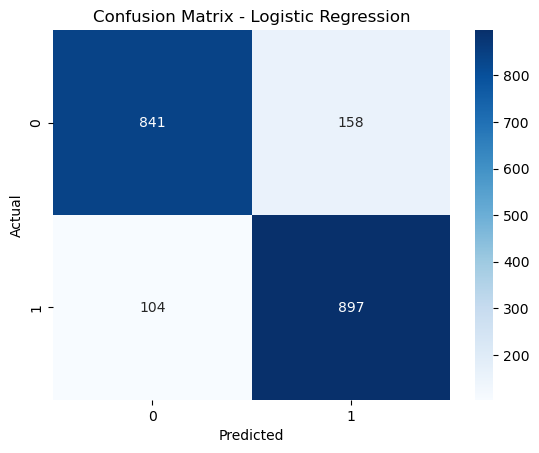

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()